In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

from rebinding.fig_utils import defaultStyle, save_fig
from rebinding.micropk import load_sol_to_model

defaultStyle(fs=14)

# Kymographs

Saving figure FigEx3_1d_kymograph_0.1


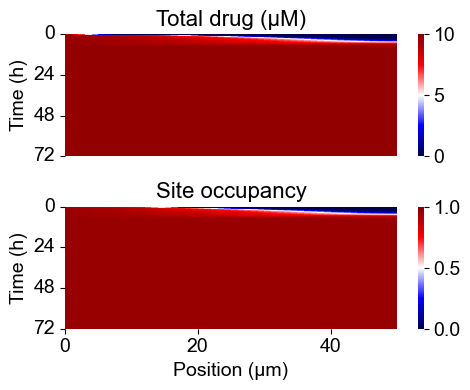

In [15]:
file_no_num = 34 # 35
micropk = load_sol_to_model(Path(f"../num_expt/cpBL{str(file_no_num).zfill(3)}/"))
fig, ax = plt.subplots(2, 1, figsize=(5, 4))
plt.subplots_adjust(wspace=0.03, hspace=0.02)
micropk.plot_kymograph(
    ax=ax,
    tspan=72 * 3600 // micropk.solver_config.dt_track,
    ylabel="Time (d)",
    vmax_c=10,
)
# micropk_approx.plot_kymograph(ax=ax[1], tspan=72 * 3600 // micropk.solver_config.dt_track, ylabel="Time (d)")
ax[0].set_title("Total drug (μM)", fontsize=16)
ax[1].set_title("Site occupancy", fontsize=16)
ax[0].set_xlabel("")
ax[0].set_xticks([])
fig.axes[2].set_label("PTX (μM)")
ax[1].set_xlabel("Position (μm)")
ax[1].set_xticks(range(0, 50, 20))
for bx in ax:
    bx.set_ylabel("Time (h)")
save_fig(f"FigEx3_1d_kymograph_{micropk.tissue_config.c0}", fmt="png", dpi=300)

# Uptake curves

Saving figure FigEx3_curves_total


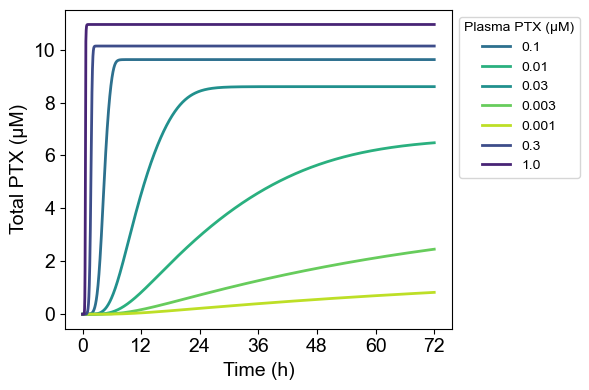

In [53]:
_, ax = plt.subplots(figsize=(6, 4))
cmap = mpl.colormaps["viridis_r"]
colors = [cmap(x) for x in np.linspace(0.1, 0.9, 7)]
c0 = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1]
c0_to_color = {c: co for c, co in zip(c0, colors)}

for file_no_num in range(34, 41):
    micropk = load_sol_to_model(Path(f"../num_expt/cpBL{str(file_no_num).zfill(3)}/"))
    ax.plot(
        micropk.t,
        micropk.sol[0][:, -1],
        lw=2,
        color=c0_to_color[micropk.tissue_config.c0],
        label=micropk.tissue_config.c0
    )
ax.set_xticks([3600 * 12 * i for i in range(7)])
ax.set_xticklabels([12 * i for i in range(7)])
ax.set_xlabel("Time (h)")
ax.set_ylabel("Total PTX (μM)")
ax.legend(title="Plasma PTX (μM)", bbox_to_anchor=(1, 1))
save_fig("FigEx3_curves_total", fmt="png", dpi=300)

Saving figure FigEx3_curves_site_occ


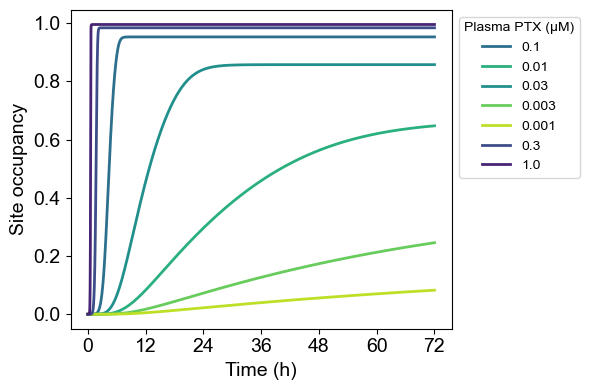

In [55]:
_, ax = plt.subplots(figsize=(6, 4))
cmap = mpl.colormaps["viridis_r"]
colors = [cmap(x) for x in np.linspace(0.1, 0.9, 7)]
c0 = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1]
c0_to_color = {c: co for c, co in zip(c0, colors)}

for file_no_num in range(34, 41):
    micropk = load_sol_to_model(Path(f"../num_expt/cpBL{str(file_no_num).zfill(3)}/"))
    ax.plot(
        micropk.t,
        micropk.sol[1][:, -1] / micropk.tissue_config.mt,
        lw=2,
        color=c0_to_color[micropk.tissue_config.c0],
        label=micropk.tissue_config.c0
    )
ax.set_xticks([3600 * 12 * i for i in range(7)])
ax.set_xticklabels([12 * i for i in range(7)])
ax.set_xlabel("Time (h)")
ax.set_ylabel("Site occupancy")
ax.legend(title="Plasma PTX (μM)", bbox_to_anchor=(1, 1))
save_fig("FigEx3_curves_site_occ", fmt="png", dpi=300)